<a href="https://colab.research.google.com/github/LukaszRoszyk/lecture1/blob/main/Copy_of_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
instalacja dodatkowych bibliotek
```



In [ ]:
!pip install lime
!pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=d910729b40bc09e1930492bc6e65be227d975868acb1bcda9dde09919df25b94
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


importy bibliotek

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# library to feature importance
import lime
from lime.lime_tabular import LimeTabularExplainer
import shap

# import the regressor and metrics
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, median_absolute_error
from sklearn.model_selection import train_test_split
from sklearn import datasets, ensemble

dane dotyczące cen domów w Kalifornii

In [ ]:
# Load the dataset
data = pd.read_csv("/content/sample_data/california_housing_train.csv")

# Display basic information about the dataset
print(data.info())
print(data.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB
None
(17000, 9)


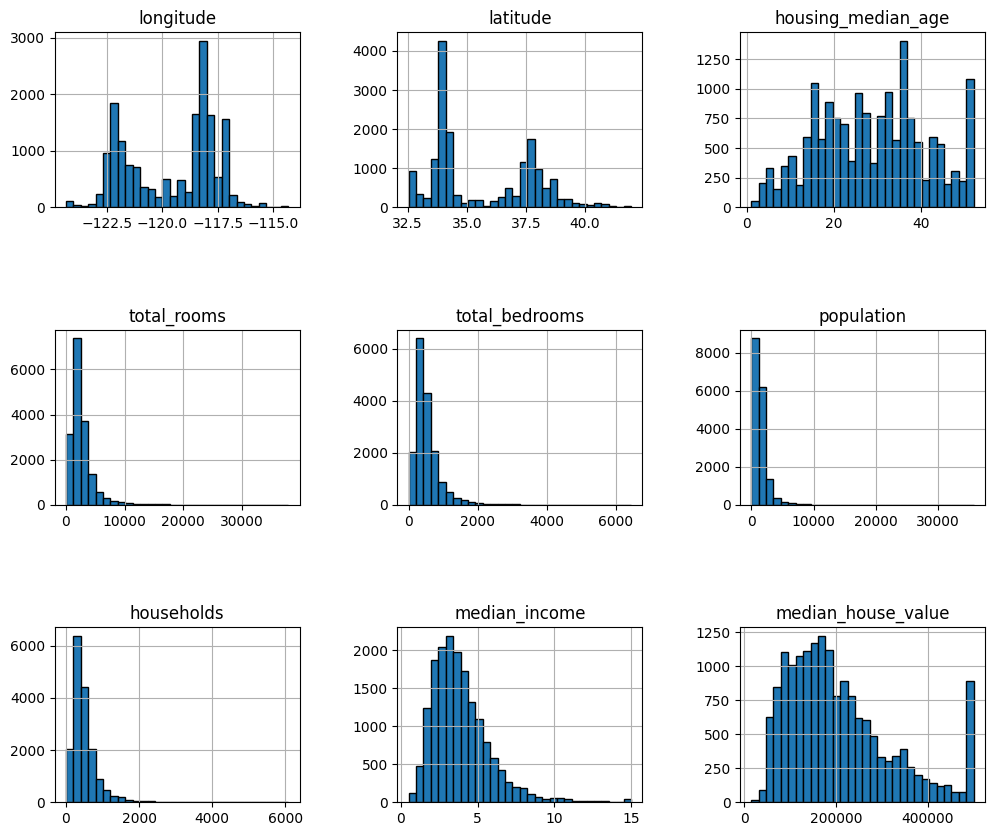

In [ ]:
import matplotlib.pyplot as plt


data.hist(figsize=(12, 10), bins=30, edgecolor="black")
plt.subplots_adjust(hspace=0.7, wspace=0.4)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

data['households'].replace("no", np.nan , inplace=True)
data['total_bedrooms'] = data['total_bedrooms'].fillna(data['total_bedrooms'].mean())

X = data.drop(["median_house_value"],axis=1)
y = data.median_house_value
# scaler = MinMaxScaler()
# scaler.fit(X)
# X = scaler.transform(X)

/tmp/ipykernel_3001/2205405142.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['households'].replace("no", np.nan , inplace=True)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=13
)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Poprawna zamiana wartości bez wywoływania SettingWithCopyWarning
data['households'] = data['households'].replace("no", np.nan)
data['total_bedrooms'] = data['total_bedrooms'].fillna(data['total_bedrooms'].mean())

X = data.drop(["median_house_value"], axis=1)
y = data['median_house_value']

# Skalowanie danych (odkomentowane)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

The root mean squared error (RMSE) XGBoost on test set: 45105.9268
The median absolute error (MAE) XGBoost on test set: 19578.1875


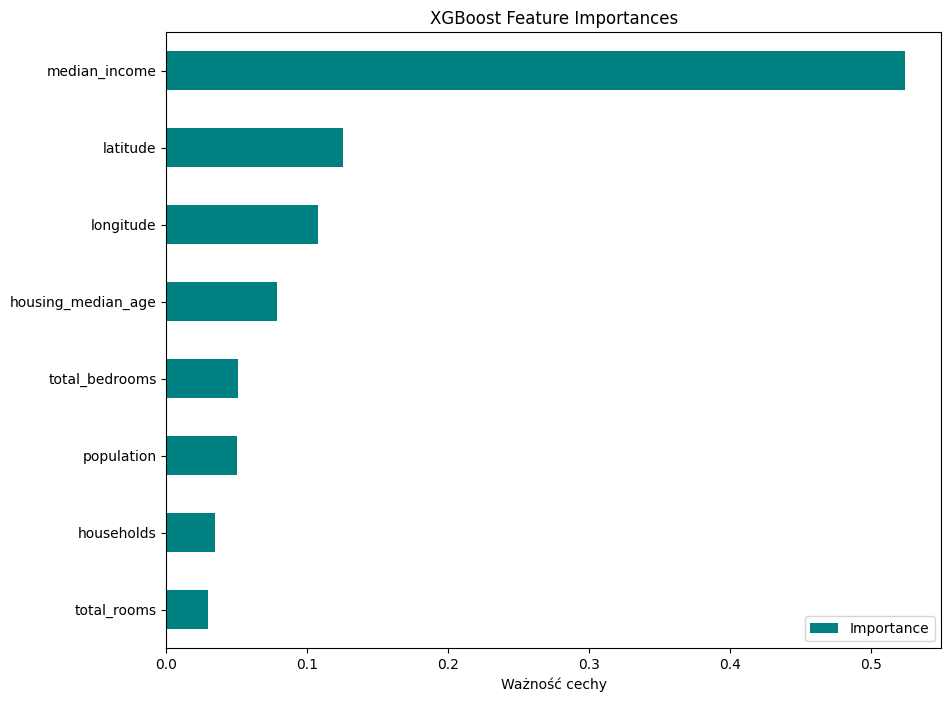

In [ ]:
import xgboost as xgb

# create XGBoost regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    random_state=13
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# Obliczenia błędów
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
median_err = median_absolute_error(y_test, y_pred_xgb)

print("The root mean squared error (RMSE) XGBoost on test set: {:.4f}".format(rmse))
print("The median absolute error (MAE) XGBoost on test set: {:.4f}".format(median_err))

# plot feature importances
feat_importances_xgb = pd.DataFrame(xgb_model.feature_importances_, index=X_train.columns, columns=["Importance"])
feat_importances_xgb.sort_values(by='Importance', ascending=True, inplace=True)
feat_importances_xgb.plot(kind='barh', figsize=(10, 8), title="XGBoost Feature Importances", color='teal')
plt.xlabel("Ważność cechy")
plt.show()

In [ ]:
import shap
import xgboost as xgb
shap.initjs()

# Ensure model is defined and trained if not present in memory
try:
    xgb_model
except NameError:
    xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=13)
    xgb_model.fit(X_train, y_train)

# Create the explainer
explainer = shap.Explainer(xgb_model, feature_names=X_train.columns)

# Evaluate SHAP values
shap_values = explainer.shap_values(X_test)

# check values for 30 - instances
# Generowanie interaktywnego wykresu dla pierwszych 30 obserwacji
shap.force_plot(explainer.expected_value, shap_values[:30], X_test.iloc[:30])

In [ ]:
explainer = lime.lime_tabular.LimeTabularExplainer(X_train.values, feature_names=X_train.columns.values.tolist(),
                                                  class_names=['median_house_value'], verbose=True, mode='regression')

# Choose the 5th instance and use it to predict the results

# plot graph

instance_index = 4
instance = X_test.iloc[instance_index].values


explanation = explainer.explain_instance(instance, regressor.predict, num_features=5)


explanation.as_pyplot_figure()
plt.tight_layout()
plt.show()


NameError: name 'regressor' is not defined

Variable Importance Plot - Global Interpretation


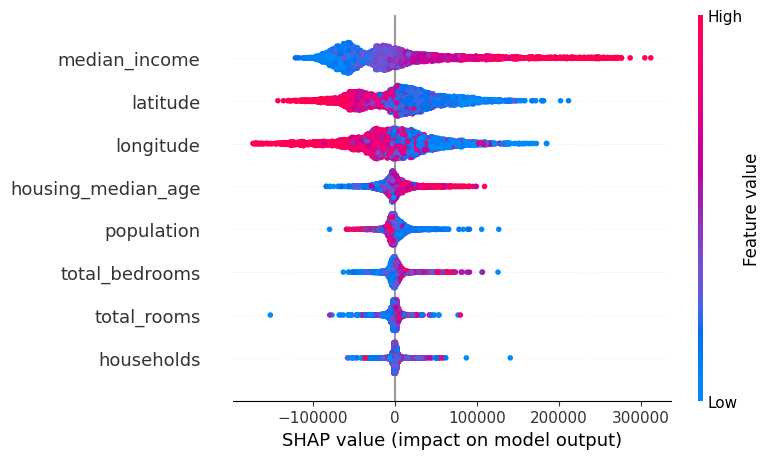

In [ ]:
# Ponowna inicjalizacja obiektu SHAP pod unikalną nazwą
shap_explainer = shap.Explainer(regressor, feature_names=X_train.columns)

# Obliczenie wartości SHAP dla zbioru testowego
shap_values = shap_explainer.shap_values(X_test)

print("Variable Importance Plot - Global Interpretation")

# Generowanie wykresu podsumowującego
shap.summary_plot(shap_values, X_test)

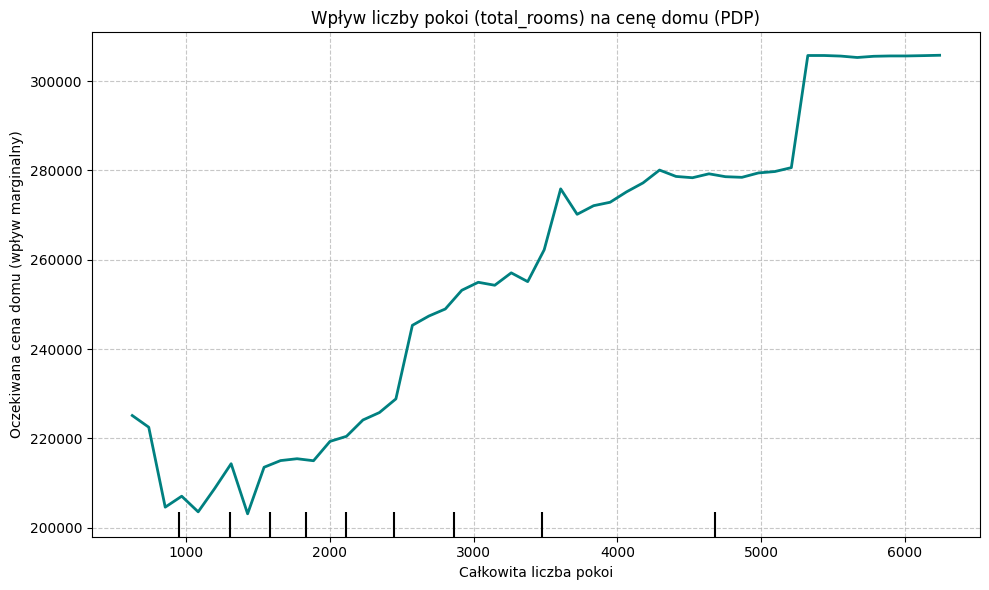

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Konfiguracja wielkości wykresu
fig, ax = plt.subplots(figsize=(10, 6))

# Generowanie wykresu PDP dla cechy 'total_rooms'
# Jako model przekazujemy nasz model XGBoost (xgb_model),
# ale możesz też wpisać 'regressor', jeśli wolisz sprawdzić Drzewo Decyzyjne.
pdp_display = PartialDependenceDisplay.from_estimator(
    estimator=xgb_model,
    X=X_train,
    features=['total_rooms'], # Lista cech do przeanalizowania
    ax=ax,
    grid_resolution=50, # Rozdzielczość siatki (im większa, tym gładszy wykres)
    line_kw={"color": "teal", "linewidth": 2}
)

plt.title("Wpływ liczby pokoi (total_rooms) na cenę domu (PDP)")
plt.xlabel("Całkowita liczba pokoi")
plt.ylabel("Oczekiwana cena domu (wpływ marginalny)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()